In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import from_bounds
import requests
import zipfile

from src.data_utils import load_config, ensure_dir

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

cfg           = load_config('../configs/config.yaml')
bbox          = cfg['region']['bbox_test']
BBOX          = [bbox['lon_min'], bbox['lat_min'], bbox['lon_max'], bbox['lat_max']]
LABEL         = '2024_04'
processed_dir = ensure_dir('../data/processed')
raw_dir       = ensure_dir('../data/raw/rusle')

print('配置加载成功')
print(f'研究区 BBOX: {BBOX}')

配置加载成功
研究区 BBOX: [147.0, -34.0, 149.0, -32.5]


In [12]:
# 下载 C 因子（直接标签）
c_url  = 'https://datasets.seed.nsw.gov.au/dataset/d40e8041-9dce-4662-a8ec-139ae04be62f/resource/736bff74-53b8-47aa-8c79-41a328b7bd4f/download/c_202404.tif'
c_path = raw_dir / 'c_202404.tif'

if c_path.exists():
    print(f'文件已存在，跳过下载: {c_path.name}')
else:
    print('正在下载 C 因子...')
    response = requests.get(c_url, stream=True)
    total    = int(response.headers.get('content-length', 0))
    with open(c_path, 'wb') as f:
        downloaded = 0
        for chunk in response.iter_content(chunk_size=1024*1024):
            f.write(chunk)
            downloaded += len(chunk)
            print(f'\r进度: {downloaded/1024/1024:.1f} / {total/1024/1024:.1f} MB', end='')
    print(f'\n下载完成')

print(f'文件大小: {c_path.stat().st_size/1024/1024:.1f} MB')

# 查看基本信息
with rasterio.open(str(c_path)) as src:
    print(f'\n坐标系  : {src.crs}')
    print(f'分辨率  : {src.res}')
    print(f'形状    : {src.width} × {src.height}')
    print(f'NoData  : {src.nodata}')
    c_data = src.read(1)
    valid  = c_data[np.isfinite(c_data) & (c_data != src.nodata)]
    print(f'\nC因子统计:')
    print(f'  最小值: {valid.min():.4f}')
    print(f'  最大值: {valid.max():.4f}')
    print(f'  均值  : {valid.mean():.4f}')
    print(f'  说明  : 0=完全植被保护，1=裸土')

正在下载 C 因子...
进度: 4.5 / 4.5 MB
下载完成
文件大小: 4.5 MB

坐标系  : EPSG:4326
分辨率  : (0.0046969999999999954, 0.004696999999999996)
形状    : 2712 × 2012
NoData  : -3.4028230607370965e+38

C因子统计:
  最小值: 0.0001
  最大值: 0.4498
  均值  : 0.0180
  说明  : 0=完全植被保护，1=裸土


In [13]:
from rasterio.warp import reproject, Resampling
from rasterio.windows import from_bounds

EPSG          = 32755
c_nodata      = -3.4028230607370965e+38

# 读取特征矩阵的空间参考
feature_tif   = processed_dir / 'NSW_test_NDVI_composite_2024_04.tif'
with rasterio.open(str(feature_tif)) as feat:
    TARGET_CRS       = feat.crs
    TARGET_TRANSFORM = feat.transform
    TARGET_HEIGHT    = feat.height
    TARGET_WIDTH     = feat.width

print(f'目标坐标系: {TARGET_CRS}')
print(f'目标形状  : {TARGET_HEIGHT} × {TARGET_WIDTH}')

# 裁切并重投影
c_reproj = np.full((TARGET_HEIGHT, TARGET_WIDTH), np.nan, dtype='float32')

with rasterio.open(str(c_path)) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=c_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=TARGET_TRANSFORM,
        dst_crs=TARGET_CRS,
        resampling=Resampling.bilinear,
        src_nodata=c_nodata,
        dst_nodata=np.nan
    )

# 裁切无效值
c_reproj[c_reproj == c_nodata] = np.nan
c_reproj = np.clip(c_reproj, 0, 1)

print(f'\n重投影完成')
print(f'形状      : {c_reproj.shape}')
print(f'有效像素  : {np.isfinite(c_reproj).mean()*100:.1f}%')
print(f'C因子范围 : {np.nanmin(c_reproj):.4f} ~ {np.nanmax(c_reproj):.4f}')
print(f'C因子均值 : {np.nanmean(c_reproj):.4f}')

目标坐标系: EPSG:32755
目标形状  : 16811 × 18790

重投影完成
形状      : (16811, 18790)
有效像素  : 100.0%
C因子范围 : 0.0001 ~ 0.4498
C因子均值 : 0.0125


图像已保存: NSW_cfactor_vs_ndvi_2024_04.png


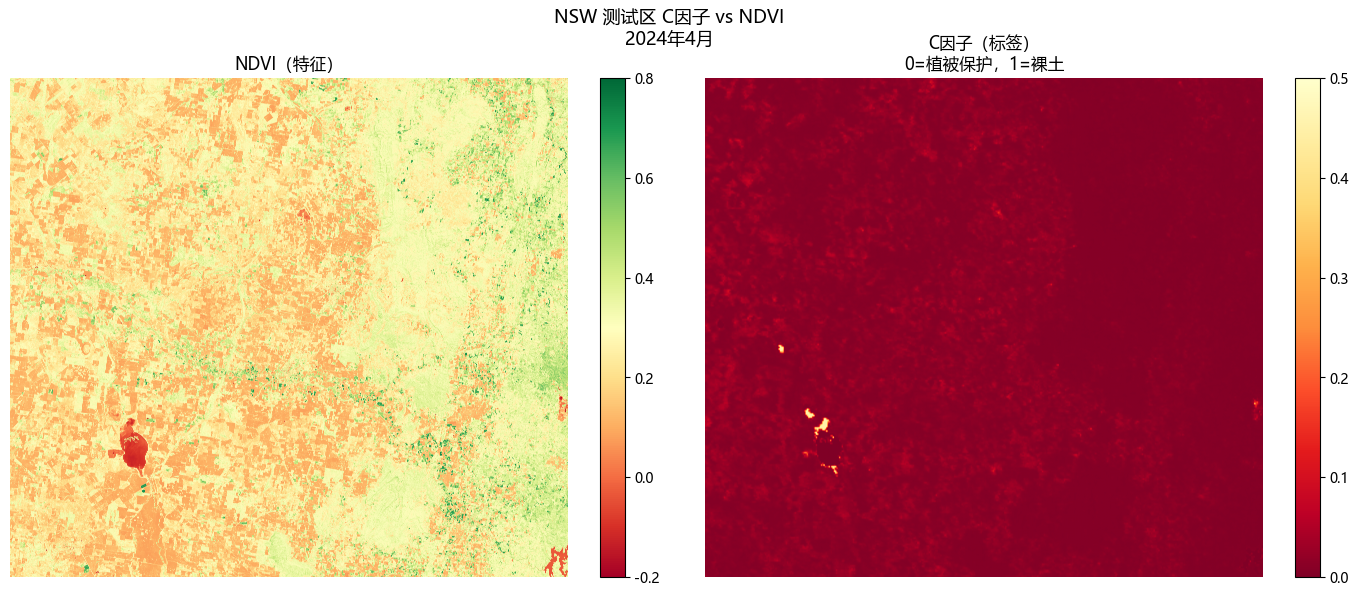

C因子标签已保存: NSW_test_cfactor_2024_04.npy
形状: (16811, 18790)
GeoTIFF已保存: NSW_test_cfactor_2024_04.tif


In [14]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NSW 测试区 C因子 vs NDVI\n2024年4月', fontsize=13)

feature_ndvi = np.load(processed_dir / 'NSW_test_features_2024_04.npy')[:,:,0]

im0 = axes[0].imshow(feature_ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[0].set_title('NDVI（特征）')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(c_reproj, cmap='YlOrRd_r', vmin=0, vmax=0.5)
axes[1].set_title('C因子（标签）\n0=植被保护，1=裸土')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
fig_dir  = ensure_dir('../results/figures')
fig_path = fig_dir / 'NSW_cfactor_vs_ndvi_2024_04.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'图像已保存: {fig_path.name}')
plt.show()

# 保存 C 因子标签
c_npy_path = processed_dir / 'NSW_test_cfactor_2024_04.npy'
np.save(c_npy_path, c_reproj)
print(f'C因子标签已保存: {c_npy_path.name}')
print(f'形状: {c_reproj.shape}')

# 保存 GeoTIFF
c_tif_path = processed_dir / 'NSW_test_cfactor_2024_04.tif'
with rasterio.open(
    str(c_tif_path), 'w', driver='GTiff',
    height=TARGET_HEIGHT, width=TARGET_WIDTH,
    count=1, dtype='float32',
    crs=TARGET_CRS, transform=TARGET_TRANSFORM,
    compress='lzw', nodata=np.nan
) as dst:
    dst.write(c_reproj, 1)
print(f'GeoTIFF已保存: {c_tif_path.name}')

In [15]:
import subprocess

commands = [
    ['git', 'add', 'notebooks/06_cfactor_label.ipynb'],
    ['git', 'add', 'results/figures/NSW_cfactor_vs_ndvi_2024_04.png'],
    ['git', 'commit', '-m', 'feat: notebook 06 - download true C-factor label from NSW SEED, 500m->10m reproject'],
    ['git', 'push']
]

for cmd in commands:
    result = subprocess.run(cmd, cwd='..', capture_output=True, text=True)
    print(' '.join(cmd))
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

git add notebooks/06_cfactor_label.ipynb
git add results/figures/NSW_cfactor_vs_ndvi_2024_04.png
git commit -m feat: notebook 06 - download true C-factor label from NSW SEED, 500m->10m reproject
[main 0dc40a8] feat: notebook 06 - download true C-factor label from NSW SEED, 500m->10m reproject
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 notebooks/06_cfactor_label.ipynb
 create mode 100644 results/figures/NSW_cfactor_vs_ndvi_2024_04.png

git push
To https://github.com/lofophil/C-NSW-factor-AI.git
   ae1281d..0dc40a8  main -> main

